In [29]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron

iris = load_iris(as_frame=True)
X = iris.data[['petal length (cm)',"petal width (cm)"]].values
y = (iris.target == 0)  

per_clf = Perceptron(random_state=42)
per_clf.fit(X,y)

X_new = [[2,0.5],[3,1]]
y_pred = per_clf.predict(X_new)
y_pred

array([ True, False])

In [2]:
# from sklearn.datasets import fetch_california_housing
# from sklearn.metrics import root_mean_squared_error
# from sklearn.model_selection import train_test_split
# from sklearn.neural_network import MLPRegressor
# from sklearn.pipeline import make_pipeline
# from sklearn.preprocessing import StandardScaler

# housing = fetch_california_housing()
# X_train_full,X_test,y_train_full,y_test = train_test_split(housing.data,housing.target,random_state=42)
# X_train,X_valid,y_train,y_valid = train_test_split(X_train_full,y_train_full,random_state=42)

# mlp_reg = MLPRegressor(hidden_layer_sizes=[50,50,50],random_state=42)
# pipeline = make_pipeline(StandardScaler(),mlp_reg)
# pipeline.fit(X_train,y_train)
# y_pred = pipeline.predict(X_valid)
# rmse = root_mean_squared_error(y_valid,y_pred)
# rmse

In [9]:
import tensorflow as tf
import keras
fashion_mnist = keras.datasets.fashion_mnist.load_data()
(X_train_full,Y_train_full) , (X_test,Y_test) = fashion_mnist
X_train,Y_train = X_train_full[:-5000],Y_train_full[:-5000]
X_valid,Y_valid = X_train_full[-5000:],Y_train_full[-5000:]

In [10]:
X_train.shape

(55000, 28, 28)

In [11]:
X_train.dtype

dtype('uint8')

In [12]:
X_train,X_valid,X_test = X_train / 255 , X_valid / 255 , X_test / 255

In [13]:
class_names = ['T-shirt / top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle-Boot']

In [14]:
class_names[Y_train[16]]

'Trouser'

In [15]:
tf.random.set_seed(42)
model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape = [28,28]))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(300,activation = 'relu'))
model.add(tf.keras.layers.Dense(100,activation = 'relu'))
model.add(tf.keras.layers.Dense(10,activation = 'softmax'))

In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# model = tf.keras.Sequential([
#     tf.keras.layers.Flatten(input_shape = [28,28]),
#     tf.keras.layers.Dense(300,activation='relu'),
#     tf.keras.layers.Dense(100,activation='relu'),
#     tf.keras.layers.Dense(10,activation = 'softmax')
# ])

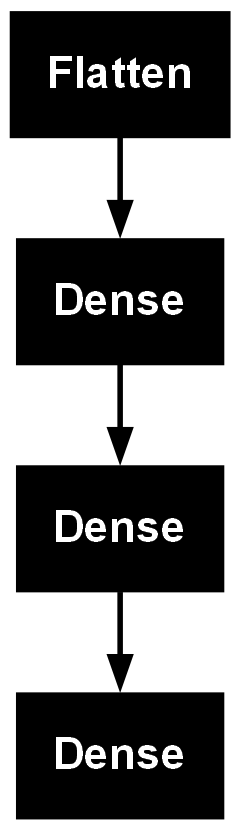

In [18]:
tf.keras.utils.plot_model(model)

In [19]:
model.layers

[<Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dense name=dense_1, built=True>,
 <Dense name=dense_2, built=True>]

In [20]:
hidden1 = model.layers[1]
hidden1.name

weights,biases = hidden1.get_weights()
weights

array([[ 0.01958813, -0.06922437, -0.06953551, ..., -0.03378978,
        -0.00715013,  0.02359319],
       [-0.00389325,  0.03238432,  0.0642312 , ...,  0.06568284,
         0.06965096,  0.06687357],
       [ 0.01468997,  0.03381012, -0.03472637, ..., -0.01082194,
         0.04576161,  0.07266457],
       ...,
       [ 0.01037968,  0.06042112, -0.07391097, ...,  0.0694342 ,
        -0.00944345, -0.01515089],
       [ 0.04611085, -0.06656623, -0.01240806, ..., -0.06120338,
         0.03741268, -0.06191292],
       [-0.03331869, -0.00843956,  0.00018737, ..., -0.01669292,
         0.03134321,  0.06149302]], dtype=float32)

In [21]:
weights.shape

(784, 300)

In [22]:
biases.shape

(300,)

In [23]:
biases

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [24]:
model.compile(loss = 'sparse_categorical_crossentropy',
              optimizer = tf.keras.optimizers.SGD(learning_rate=0.002),
              metrics = ['accuracy'])

In [25]:
Y_hot_train = tf.keras.utils.to_categorical(Y_train) # Used for one hot encoding

In [26]:
np.argmax(Y_hot_train,axis = 1) # for converting one-hot encoded labels into simple implementations

NameError: name 'np' is not defined

In [34]:
history = model.fit(X_train,Y_train,epochs = 30,validation_data = (X_valid,Y_valid))

Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8311 - loss: 0.5038 - val_accuracy: 0.8372 - val_loss: 0.4855
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8358 - loss: 0.4854 - val_accuracy: 0.8394 - val_loss: 0.4718
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8402 - loss: 0.4710 - val_accuracy: 0.8428 - val_loss: 0.4610
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8437 - loss: 0.4591 - val_accuracy: 0.8448 - val_loss: 0.4518
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8466 - loss: 0.4490 - val_accuracy: 0.8474 - val_loss: 0.4439
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8497 - loss: 0.4403 - val_accuracy: 0.8488 - val_loss: 0.4370
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8522 - loss: 0.4326 - val_accuracy: 0.8500 - val_loss: 0.4311
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8545 - loss: 0.4256 - 

In [36]:
history.params

{'verbose': 'auto', 'epochs': 30, 'steps': 1719}

In [37]:
history.epoch

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29]

In [38]:
history.history

{'accuracy': [0.8323818445205688,
  0.8365636467933655,
  0.8409090638160706,
  0.8444545269012451,
  0.8469818234443665,
  0.8500000238418579,
  0.8524181842803955,
  0.8551272749900818,
  0.857200026512146,
  0.85914546251297,
  0.8606181740760803,
  0.8621636629104614,
  0.8636727333068848,
  0.8647817969322205,
  0.8663636445999146,
  0.8675636649131775,
  0.8690181970596313,
  0.870090901851654,
  0.8712727427482605,
  0.8723999857902527,
  0.8734545707702637,
  0.874890923500061,
  0.8759272694587708,
  0.8767818212509155,
  0.8776545524597168,
  0.8785454630851746,
  0.8798545598983765,
  0.8804181814193726,
  0.8811091184616089,
  0.8819090723991394],
 'loss': [0.49598878622055054,
  0.4787861108779907,
  0.465175062417984,
  0.4539532959461212,
  0.44436633586883545,
  0.43605226278305054,
  0.4286420941352844,
  0.42195752263069153,
  0.41582417488098145,
  0.4102362096309662,
  0.4050595164299011,
  0.40022119879722595,
  0.39568692445755005,
  0.3913578391075134,
  0.387189

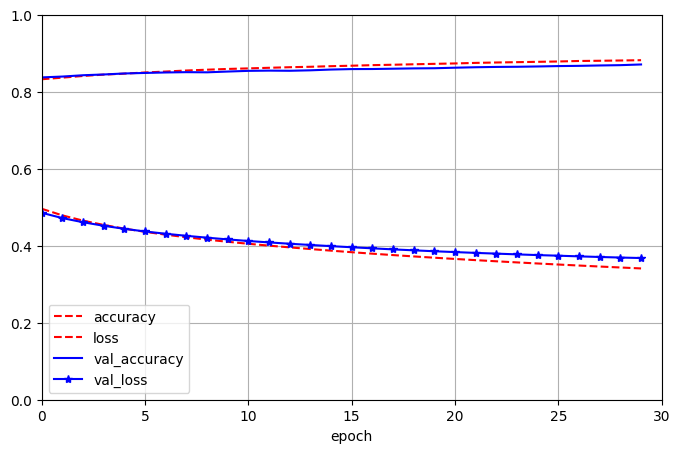

In [40]:
import matplotlib.pyplot as plt
import pandas as pd

pd.DataFrame(history.history).plot(
    figsize=(8,5),xlim = [0,30],ylim = [0,1],grid = True,xlabel='epoch',style = ['r--','r--','b-','b-*']
)
plt.show()

In [41]:
model.evaluate(X_test,Y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8650 - loss: 0.3900


[0.39481642842292786, 0.8619999885559082]

In [42]:
X_new = X_test[:3]

In [43]:
y_proba = model.predict(X_new)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


In [45]:
y_proba.round(2)

array([[0.  , 0.  , 0.  , 0.  , 0.  , 0.18, 0.  , 0.13, 0.  , 0.69],
       [0.  , 0.  , 0.98, 0.  , 0.01, 0.  , 0.01, 0.  , 0.  , 0.  ],
       [0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ]],
      dtype=float32)

In [46]:
y_pred = y_proba.argmax(axis = 1)
y_pred

array([9, 2, 1], dtype=int64)

In [48]:
import numpy as np
np.array(class_names)[y_pred]

array(['Ankle-Boot', 'Pullover', 'Trouser'], dtype='<U13')

In [49]:
tf.random.set_seed(42)

In [50]:
norm_layer = keras.layers.Normalization(input_shape = X_train.shape[1:])
model = keras.Sequential([
    norm_layer,
    keras.layers.Dense(50,activation='relu'),
    keras.layers.Dense(50,activation='relu'),
    keras.layers.Dense(50,activation='relu'),
    keras.layers.Dense(1)
])

optimizer = keras.optimizers.Adam(learning_rate=1e-3)
model.compile(loss = 'mse',optimizer = optimizer, metrics = ['RootMeanSquaredError'])
norm_layer.adapt(X_train)

history = model.fit(X_train,Y_train,epochs = 20,validation_data=(X_valid,Y_valid))
mse_test,rmse_test = model.evaluate(X_test,Y_test)
X_new = X_test[:3]
y_pred = model.predict(X_new)

c:\Users\jitik\anaconda3\Lib\site-packages\keras\src\layers\preprocessing\tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - RootMeanSquaredError: 3.0815 - loss: 9.5916 - val_RootMeanSquaredError: 2.9010 - val_loss: 8.4158
Epoch 2/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - RootMeanSquaredError: 2.8826 - loss: 8.3097 - val_RootMeanSquaredError: 2.9001 - val_loss: 8.4104
Epoch 3/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - RootMeanSquaredError: 2.8785 - loss: 8.2856 - val_RootMeanSquaredError: 2.9006 - val_loss: 8.4134
Epoch 4/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - RootMeanSquaredError: 2.8768 - loss: 8.2761 - val_RootMeanSquaredError: 2.8979 - val_loss: 8.3979
Epoch 5/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - RootMeanSquaredError: 2.8756 - loss: 8.2692 - val_RootMeanSquaredError: 2.8952 - val_loss: 8.3822
Epoch 6/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - RootMeanSquaredError: 2.8746 - loss: 8.2632 - val_RootMeanSquaredError: 2.8937 - val_loss: 8.3734
Epoch 7/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - RootMeanSquaredError

In [51]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 28, 28)         │            57 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 28, 50)         │         1,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 28, 50)         │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 28, 50)         │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 28, 1)          │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,862 (77.59 KB)

 Trainable params: 6,601 (25.79 KB)

 Non-trainable params: 57 (232.00 B)

 Optimizer params: 13,204 (51.58 KB)